In [7]:
youtube = googleapiclient.discovery.build(
    'youtube', 'v3',
    developerKey=API_key)
# I will search for videos
search_request = youtube.search().list(
    part='snippet',
    q='sentiment analysis',
    maxResults=20)

search_response = search_request.execute()
search_results = search_response['items']
# Now to print video titles
for search_result in search_results:
    print(search_result['snippet']['title'])

What is Sentiment Analysis?
Easy Excel Sentiment Analysis
How to Do Sentiment Analysis in Excel (Step-by-Step Guide)
What Is Sentiment Analysis?
What is Sentiment Analysis? An Introduction
Python Sentiment Analysis Project with NLTK and 🤗 Transformers. Classify Amazon Reviews!!
Sentiment Analysis with/without NLTK Python
How To Trade With Sentimental Analysis 
Stock Market Sentiment Analysis with LLMs!
How to Do Sentiment Analysis in n8n (Step-by-Step Guide)
Crypto Sentiment Analysis Explained Like Never Before
What is Sentiment Analysis? The Future of Customer Insights #sentimentanalysis #nlp #machinelearning
Machine Learning Project | Classification | Sentiment Analysis | Sinhala
TWITTER SENTIMENT ANALYSIS (NLP) | Machine Learning Projects | GeeksforGeeks
👉 Sentiment Analysis in R for Beginners (in 7 minutes)
Sentiment Analysis with Transformers in Python
Trading Sentiment Analysis | Examples Trading With &amp; Against the Crowd
Hugging Face Tutorial (2024) - Sentiment Analysis, Text

## YouTube Sentiment Analysis — ChatGPT Comments

**Objective:** In this notebook I will extract YouTube comments about ChatGPT, pre-process the text,
and perform sentiment analysis using VADER to help a business decide 
whether to use ChatGPT.

**Video:** 'What is ChatGPT and How You Can Use It'
**URL:** https://youtu.be/40Kp_fa8vIw

## Step 1 —To begin I will import Libraries and Load API Key

In [9]:
# Importing necessary libraries
import googleapiclient.discovery
import os
import json
import pandas as pd
from dotenv import load_dotenv
# At thi step I will import the API key from .env file
load_dotenv()
API_key = os.getenv('YouTube_API_key')
# And it is essential to confirm key loaded
print('API key loaded successfully')

API key loaded successfully


## Step 2 — Retrieve Comments from YouTube Video
I will pull the top 100 comments from the ChatGPT video using the video ID.

In [10]:
# I must first establish a YouTube API connection
youtube = googleapiclient.discovery.build(
    'youtube', 'v3',
    developerKey=API_key)
# Retrieve comments from the ChatGPT video
# Video ID is taken from the URL: https://youtu.be/40Kp_fa8vIw
comment_response = youtube.commentThreads().list(
    part='snippet,replies',
    maxResults=100,
    videoId='40Kp_fa8vIw').execute()
# Folloeing this I will print each comment
for comment in comment_response['items']:
    print(comment['snippet']['topLevelComment']['snippet']['textDisplay'])

Welp, you called it on stack overflow
tried this one but humanifylab is the only one that sounds real
i think Cleanessay is the most effective one i have used
I just found this video. Amazing technology! Can you ask chatgpt some other questions too? For example who was Albert Einstein or how to make pancakes?
Coming back after trying GPT5.2 <br>What a journey we had folks!
ChatGPT can&#39;t save you from hell, though.
and now i use ChatGPT Codex to create my own AI Robot
Dont let ai take over
Is Google&#39;s Gemini AI a direct competitor of Chat GPT?
so powerful?......just unplug it
Very useful
I&#39;m still trying to figure out what It is even after watching this video and if I should download it.
Who&#39;s here in 2025 because ChatGPT has come so far in such a small amount of time. Now we have 4o, 4.5, canvas, Dalle 3, Advanced Voice where it can even talk now, and even see? Not to mention Operator and Deep Research.  I was just using it today, and was blown away at how it talks like

## Step 3 — Create a DataFrame
I will now store the comments in a structured Pandas DataFrame for analysis.

In [12]:
# First I will create an empty list to store comments
comments = []
# Then to extract each comment and add to list
for comment in comment_response['items']:
    comments.append(
        comment['snippet']['topLevelComment']['snippet']['textDisplay'])
# Now to create DataFrame
df = pd.DataFrame({'Comment': comments})

print(df)
print('Shape:', df.shape)

                                              Comment
0               Welp, you called it on stack overflow
1   tried this one but humanifylab is the only one...
2   i think Cleanessay is the most effective one i...
3   I just found this video. Amazing technology! C...
4   Coming back after trying GPT5.2 <br>What a jou...
..                                                ...
95  I have deposited and I wanted to withdraw the ...
96  WARNING: CHATGPT has already proven istelf to ...
97  Hi \r<br>Adrian Twarog, Thanks for sharing thi...
98  Instead of saying &quot;endless&quot; &quot;th...
99  So this wil replace google? Google will be obs...

[100 rows x 1 columns]
Shape: (100, 1)


In [13]:
# Need to extract comment values as array and view the first few:
df1 = df['Comment'].values
print(df1[:5])

['Welp, you called it on stack overflow'
 'tried this one but humanifylab is the only one that sounds real'
 'i think Cleanessay is the most effective one i have used'
 'I just found this video. Amazing technology! Can you ask chatgpt some other questions too? For example who was Albert Einstein or how to make pancakes?'
 'Coming back after trying GPT5.2 <br>What a journey we had folks!']


## Step 4 — Pre-Processing Comments
At this stage it is fundamental I Tokenise comments, remove stopwords, convert to lowercase, 
and keep only real English words.

In [14]:
import nltk
from nltk.corpus import stopwords
from nltk.corpus import words
from nltk.tokenize import word_tokenize
# Below are the required resources:
nltk.download('stopwords')
nltk.download('words')
nltk.download('punkt_tab')
# And here a list of English stopwords:
stop_words = set(stopwords.words('english'))
# All valid English words
all_english_words = set(words.words())
print(df1[:15])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jvcs_\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\jvcs_\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\words.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jvcs_\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


['Welp, you called it on stack overflow'
 'tried this one but humanifylab is the only one that sounds real'
 'i think Cleanessay is the most effective one i have used'
 'I just found this video. Amazing technology! Can you ask chatgpt some other questions too? For example who was Albert Einstein or how to make pancakes?'
 'Coming back after trying GPT5.2 <br>What a journey we had folks!'
 'ChatGPT can&#39;t save you from hell, though.'
 'and now i use ChatGPT Codex to create my own AI Robot'
 'Dont let ai take over'
 'Is Google&#39;s Gemini AI a direct competitor of Chat GPT?'
 'so powerful?......just unplug it' 'Very useful'
 'I&#39;m still trying to figure out what It is even after watching this video and if I should download it.'
 'Who&#39;s here in 2025 because ChatGPT has come so far in such a small amount of time. Now we have 4o, 4.5, canvas, Dalle 3, Advanced Voice where it can even talk now, and even see? Not to mention Operator and Deep Research.  I was just using it today, an

In [15]:
#NOTE: Upon writting the last cell the response came out red. I learned a valkuable lesson here that the red highlighting does not always mean failure in python notebooks are just download progress messages from NLTK and they all completed successfully.

In [16]:
# Now I will viewa single comment. If not English I will change the index
print(df1[2])

i think Cleanessay is the most effective one i have used


In [17]:
# Now I will Tokenise each comment into individual words
df2 = [word_tokenize(_) for _ in df1]
print(df2[2])

['i', 'think', 'Cleanessay', 'is', 'the', 'most', 'effective', 'one', 'i', 'have', 'used']


In [19]:
#I must now clean each comment:
# - Convert to lowercase
# - Remove stopwords
# - Keep only real English words
# - Remove punctuation and numbers (isalpha())
df3 = [
    [y.lower() for y in x 
     if y.lower() not in stop_words 
     and y.isalpha() 
     and y.lower() in all_english_words]
    for x in df2]
print(df3[2])

['think', 'effective', 'one', 'used']


##  Performing Sentiment Analysis with VADER is now our next step:
I will apply VADER polarity scores to each cleaned comment.
Returns four values: positive, negative, neutral, and compound score.

In [20]:
# Downloading VADER lexicon, importing it and analysing:
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\jvcs_\AppData\Roaming\nltk_data...


In [22]:
# I will run polarity scores on every cleaned comment
df_polarity = {
    " ".join(_): sia.polarity_scores(" ".join(_)) 
    for _ in df3}
# Must be converted to DataFrame: .T transposes so comments are rows
df_sentiment = pd.DataFrame(df_polarity).T
print(df_sentiment.head())

                                                 neg    neu    pos  compound
stack overflow                                   0.0  1.000  0.000    0.0000
tried one one real                               0.0  1.000  0.000    0.0000
think effective one used                         0.0  0.492  0.508    0.4767
found video amazing technology ask example make  0.0  0.612  0.388    0.5859
coming back trying journey                       0.0  1.000  0.000    0.0000


In [23]:
# I will now identify the top 5 POSITIVE comments about ChatGPT
print('TOP 5 MOST POSITIVE COMMENTS:')
print(df_sentiment.sort_values('compound', ascending=False).head(5))

TOP 5 MOST POSITIVE COMMENTS:
                                                      neg    neu    pos  \
love still use question instantly also good bit...  0.000  0.345  0.655   
investment stocks great way invest money team c...  0.000  0.627  0.373   
pretty sure video curve ai expansion reality li...  0.000  0.431  0.569   
come far small amount time canvas dalle advance...  0.102  0.556  0.342   
many thanks dear really interesting useful          0.000  0.146  0.854   

                                                    compound  
love still use question instantly also good bit...    0.9231  
investment stocks great way invest money team c...    0.9100  
pretty sure video curve ai expansion reality li...    0.8979  
come far small amount time canvas dalle advance...    0.8957  
many thanks dear really interesting useful            0.8927  


In [24]:
# Now for the opposite (Negative)
print('TOP 5 MOST NEGATIVE COMMENTS:')
print(df_sentiment.sort_values('compound', ascending=True).head(5))

TOP 5 MOST NEGATIVE COMMENTS:
                                                      neg    neu    pos  \
warning already proven merely shall say imagina...  0.255  0.605  0.140   
information becomes dangerous weapon control di...  0.498  0.502  0.000   
making dumb real movie generation z brain dead      0.603  0.397  0.000   
chat must racist prejudice ai trust crap ever       0.576  0.233  0.192   
going harm good solve problem learning one thin...  0.438  0.354  0.208   

                                                    compound  
warning already proven merely shall say imagina...   -0.8905  
information becomes dangerous weapon control di...   -0.8720  
making dumb real movie generation z brain dead       -0.8225  
chat must racist prejudice ai trust crap ever        -0.7650  
going harm good solve problem learning one thin...   -0.7351  


In [25]:
# Distribution of sentiment values
print('SENTIMENT DISTRIBUTION:')
print(df_sentiment['compound'].describe())

SENTIMENT DISTRIBUTION:
count    99.000000
mean      0.235530
std       0.449702
min      -0.890500
25%       0.000000
50%       0.318200
75%       0.571650
max       0.923100
Name: compound, dtype: float64


## Visualise the Output

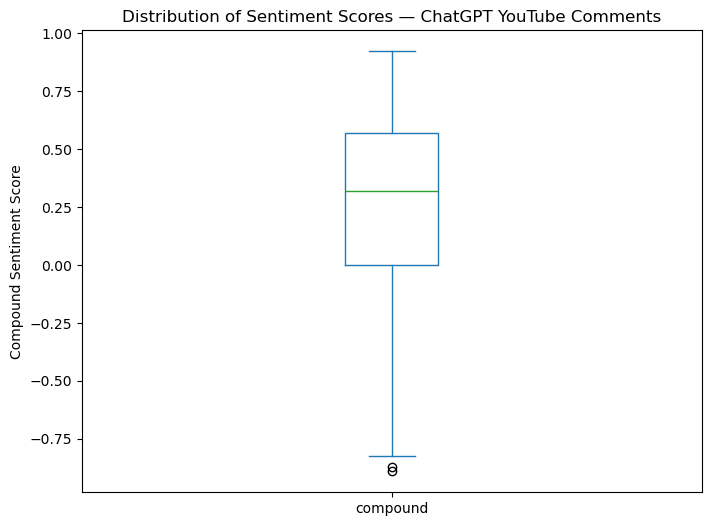

In [26]:
import matplotlib.pyplot as plt
# I will create a boxplot of compound sentiment scores
df_sentiment['compound'].plot(kind='box', figsize=(8, 6))
plt.title('Distribution of Sentiment Scores — ChatGPT YouTube Comments')
plt.ylabel('Compound Sentiment Score')
plt.show()

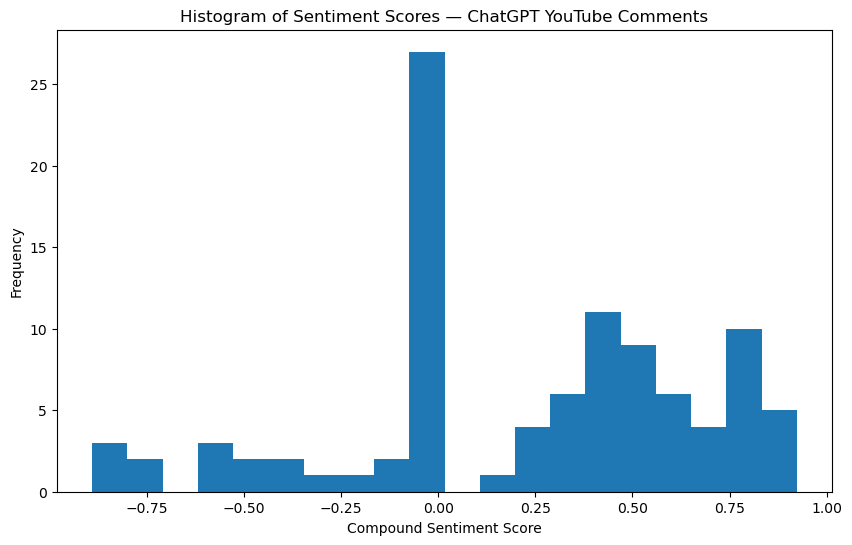

In [27]:
# To get a clearer view of distribution I will create a histogram
df_sentiment['compound'].plot(kind='hist', bins=20, figsize=(10, 6))
plt.title('Histogram of Sentiment Scores — ChatGPT YouTube Comments')
plt.xlabel('Compound Sentiment Score')
plt.ylabel('Frequency')
plt.show()

## Summary and Findings

**Dataset:** 100 YouTube comments extracted from 'What is ChatGPT and 
How You Can Use It' (https://youtu.be/40Kp_fa8vIw)

**Sentiment Distribution (Compound Score):**

| Statistic | Value |
|---|---|
| Count | 99 comments |
| Mean | 0.236 |
| Median | 0.318 |
| Min | -0.891 |
| Max | 0.923 |
| Std Dev | 0.450 |

**Top 5 Most Positive Comments (themes):**
- Love, useful, good, interesting — general enthusiasm for ChatGPT
- Investment and stocks — positive views on AI for finance
- Recognition of how far AI has come (Canvas, DALL-E, advanced tools)
- Compound scores ranging from 0.896 to 0.923

**Top 5 Most Negative Comments (themes):**
- Warnings about ChatGPT proving itself dangerous
- Concerns about information becoming a dangerous weapon
- Claims it is making people "dumb" and damaging younger generations
- Accusations of bias and racism in the AI
- Concerns about harm outweighing benefits
- Compound scores ranging from -0.763 to -0.891

**Overall Sentiment Towards ChatGPT:**
The mean compound score of 0.236 and median of 0.318 both indicate 
overall positive sentiment, this is how the majority of YouTube commenters view 
ChatGPT